In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
from eqnet_independent_copy import EqNet, GaussianDiffusion, DiffuserTrainer, DiffuserPlanner, CompositeReward, expand_spline_from_skip_list, StartReachingReward, GoalReachingReward, SkipTotalTimeSkipPenalty, CurvaturePenalty
from point_maze_skip import MinariTrajectoryDatasetWithPseudoActions
import torch
from matplotlib.patches import Rectangle
import mujoco
from torch.utils.data import DataLoader, Dataset



class OfflineSkipDataset(Dataset):
    """
    Loads precomputed, normalized windows (N, horizon, 3)
    from an .npz archive that also contains normalization statistics.

    Mirrors exactly the attributes of MinariTrajectoryDatasetIndependentSkips:
        - state_dim = 2
        - action_dim = 1
        - traj_dim = 3
        - pos_mean, pos_std
        - flat_mean, flat_std
        - skip_mean, skip_std
        - mean, std  (full 3-dim stats)
    """

    def __init__(self, file_path, horizon=32):
        archive = np.load(file_path)

        # -------------------------------------------------------
        # Load normalized trajectory data
        # -------------------------------------------------------
        data = archive["data"]  # (N, H, 3)
        assert data.ndim == 3 and data.shape[1] == horizon

        self.data = torch.from_numpy(data).float()
        self.horizon = horizon

        # Exactly match MinariIndependent dims
        self.state_dim = 2          # (x, y)
        self.action_dim = 1         # skip
        self.traj_dim = 3           # 2 + 1

        # -------------------------------------------------------
        # Load same normalization fields as the on-the-fly dataset
        # -------------------------------------------------------

        # Position normalization
        self.pos_mean = archive["flat_mean"].astype(np.float32)  # (2,)
        self.pos_std  = archive["flat_std"].astype(np.float32)   # (2,)

        # IMPORTANT: aliases so planner code works
        self.flat_mean = self.pos_mean
        self.flat_std  = self.pos_std

        # Skip normalization
        self.skip_mean = float(archive["skip_mean"])
        self.skip_std  = float(archive["skip_std"])

        # Full 3-d normalization (for denorm in planner)
        self.mean = archive["full_mean"].astype(np.float32)      # (3,)
        self.std  = archive["full_std"].astype(np.float32)       # (3,)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        """
        Returns: (H, 3) tensor:
            [:,0:2] normalized positions
            [:,2]   normalized skip
        """
        return self.data[idx]

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

USE_POSITIONAL_ENCODING = False

print("\n" + "=" * 80)
print("EQ-NET CONFIGURATION")
print("=" * 80)
print(f"Positional Encoding: {USE_POSITIONAL_ENCODING}")
print("Architecture: Local convolutions (no downsampling) for shift equivariance")
print("Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)")

    # ========================================================================
    # DATA
    # ========================================================================

# Use pseudo-action dataset
#dataset = MinariTrajectoryDatasetWithPseudoActions(
    #"D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
#)

OFFLINE_FILE = "/scratch/network/ts4953/dataset_gen/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/datasets/fixed_offline_umaze_independent_skips_h32_mu1_sig1.npz"

dataset = OfflineSkipDataset(
    OFFLINE_FILE,
    horizon=32
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")


Using device: cuda

EQ-NET CONFIGURATION
Positional Encoding: False
Architecture: Local convolutions (no downsampling) for shift equivariance
Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)

Dataset size: 1321000 trajectory windows
Trajectory dim (pos+skip): 3


In [16]:
# ========================================================================
    # MODEL
    # ========================================================================

eqnet = EqNet(
        state_dim=dataset.traj_dim,
        hidden_dim=128,
        time_dim=32,
        n_layers=10,  # Deep but local
    )

diffusion = GaussianDiffusion(timesteps=200)

print(f"\nModel parameters: {sum(p.numel() for p in eqnet.parameters()):,}")



Model parameters: 1,506,179


In [17]:
# ========================================================================
# TRAINING
# ========================================================================

trainer = DiffuserTrainer(
        model = eqnet,
        diffusion = diffusion,
        dataset=dataset,
        device = device,
    )

TRAIN_NEW = False
if TRAIN_NEW:
    print("\n" + "=" * 80)
    print("TRAINING")
    print("=" * 80)
    trainer.train(epochs=100, save_every=1)
else:
    print("\nLoading pre-trained model...")
    try:
        trainer.load("/scratch/network/ts4953/dataset_gen/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/diffuser/checkpoints/diffuser_fixed_h32_m1_s1_epoch_10.pt")
        print("Loaded checkpoint successfully")
    except:
        print("No checkpoint found, using random initialization")

trainer.use_ema_for_inference()


Loading pre-trained model...
Loaded checkpoint successfully
Switched to EMA parameters for inference


In [18]:
# ========================================================================
# PLANNING
# ========================================================================


planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

current = np.array([1, 1, 0.88507522, 4.78210334])
goal = np.array([-1, -1])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.0),
        CurvaturePenalty(reward_scale=0.1),
    ]
)

print("\n" + "=" * 80)
print("PLANNING WITH EQ-NET (pos + skip)")
print("=" * 80)

# Experiment 1: standard planning
print("\n--- Experiment 1: Standard Planning ---")
traj = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=24,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)
coarse, = traj["coarse"],
coarse_pos= traj["coarse_pos"] 
coarse_skip=traj["coarse_skip"]              # (H,)
skip = traj["skip_list"]     # [(pos_i, skip_i)]
pos_dense=traj["pos_dense"]           # (N,2)
vel_dense=traj["vel_dense"]           # (N,2)
acc_dense=traj["acc_dense"]           # (N,2)  
print(f"Start (actual): {pos_dense[0]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(pos_dense[0] - current[:2]):.4f}")
print(f"End: {pos_dense[-1]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(pos_dense[-1] - goal):.4f}")
print("\n" + "=" * 80)
print("EXPERIMENTS COMPLETE")
print("=" * 80)
print(pos_dense)


PLANNING WITH EQ-NET (pos + skip)

--- Experiment 1: Standard Planning ---
Start (actual): [1.00256765 1.05826652]
Start (target): [1. 1.]
Start error: 0.0583
End: [-0.99996853 -0.99791807]
Goal: [-1 -1]
Goal error: 0.0021

EXPERIMENTS COMPLETE
[[ 1.00256765e+00  1.05826652e+00]
 [ 9.97872721e-01  1.04600948e+00]
 [ 9.85876701e-01  1.01693124e+00]
 [ 9.69712738e-01  9.82571125e-01]
 [ 9.52513979e-01  9.54468472e-01]
 [ 9.37413573e-01  9.44162607e-01]
 [ 9.29123039e-01  9.56444704e-01]
 [ 9.20832506e-01  9.68726802e-01]
 [ 9.00741577e-01  9.51039135e-01]
 [ 8.79212122e-01  9.18459916e-01]
 [ 8.57682667e-01  8.85880696e-01]
 [ 8.35762143e-01  8.58400166e-01]
 [ 8.07346274e-01  8.28519537e-01]
 [ 7.77437568e-01  7.97492623e-01]
 [ 7.50680996e-01  7.69696075e-01]
 [ 7.22348809e-01  7.41378486e-01]
 [ 6.97285448e-01  7.17131226e-01]
 [ 6.72016144e-01  6.93663597e-01]
 [ 6.43590003e-01  6.68341192e-01]
 [ 6.14220321e-01  6.43279254e-01]
 [ 5.81127238e-01  6.17954871e-01]
 [ 5.47525465e-01  

In [9]:

env_dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
)
env = env_dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model = env.model
mj_data = env.data


=== Trajectory 1/10 ===

=== Trajectory 2/10 ===

=== Trajectory 3/10 ===

=== Trajectory 4/10 ===

=== Trajectory 5/10 ===

=== Trajectory 6/10 ===

=== Trajectory 7/10 ===

=== Trajectory 8/10 ===

=== Trajectory 9/10 ===

=== Trajectory 10/10 ===


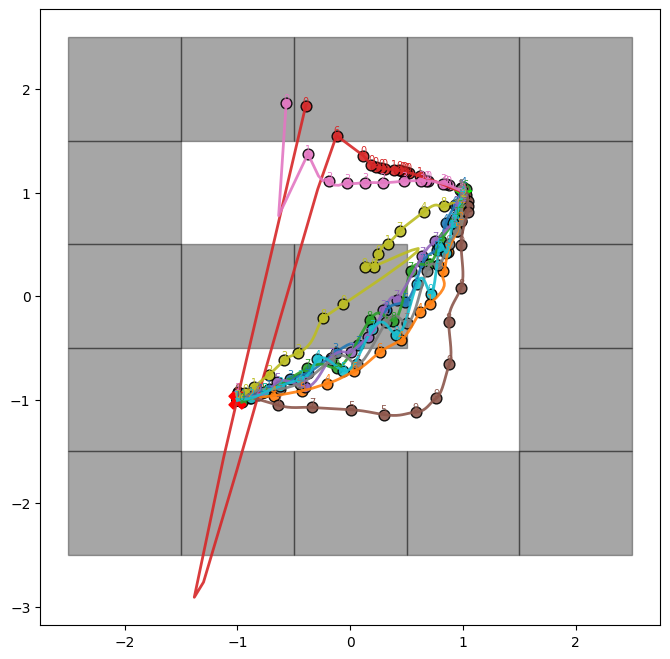

In [20]:
num_samples = 10   # number of trajectories to sample
#WHEN USING THE 48 HORIZON, REMEMBER TO CHANGE HORIZON IN CODE...?
fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab10(np.linspace(0, 1, num_samples))

for k in range(num_samples):
    print(f"\n=== Trajectory {k+1}/{num_samples} ===")

    traj = planner.plan_and_reconstruct(
        current,
        goal,
        reward_fn=reward_fn,
        horizon=16,
        guidance_scale=1.0,
        condition_on_start=True,
        condition_on_goal=True,
        conditioning_schedule="constant",
        conditioning_strength=0.9,
        spline_func=expand_spline_from_skip_list,
    )

    pos_dense   = traj["pos_dense"]
    coarse_pos  = traj["coarse_pos"]
    coarse_skip = traj["coarse_skip"]

    color = colors[k]

    # -----------------------------------------------------------
    # Dense trajectory (THE ONLY LABEL)
    # -----------------------------------------------------------
    ax.plot(
        pos_dense[:, 0],
        pos_dense[:, 1],
        linewidth=2,
        color=color,
        alpha=0.9,
        label=f"Trajectory {k+1}"
    )

    # -----------------------------------------------------------
    # Coarse waypoints (NO LEGEND LABEL)
    # -----------------------------------------------------------
    ax.scatter(
        coarse_pos[:, 0],
        coarse_pos[:, 1],
        s=60,
        c=[color],
        edgecolors="k",
        alpha=0.9,
        label=None     # <--- IMPORTANT: no extra legend entry
    )

    # Skip labels
    for i, (x, y) in enumerate(coarse_pos):
        ax.text(x, y, f"{int(coarse_skip[i])}",
                fontsize=7, ha="center", va="bottom", color=color)

# -----------------------------------------------------------
# Start + Goal
# -----------------------------------------------------------
ax.scatter(current[0], current[1], s=150, marker="*", color="lime", label="Start")
ax.scatter(goal[0],    goal[1],    s=150, marker="X", color="red",  label="Goal")

# -----------------------------------------------------------
# Maze walls (mj_model already available)
# -----------------------------------------------------------
for geom_id in range(mj_model.ngeom):
    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)

    # Only render maze walls (named "block", like in PointMaze)
    if name is None or ("block" not in name):
        continue

    pos = mj_model.geom_pos[geom_id]      # (x, y, z) center
    size = mj_model.geom_size[geom_id]    # half-sizes (hx, hy, hz)

    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx, 2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)


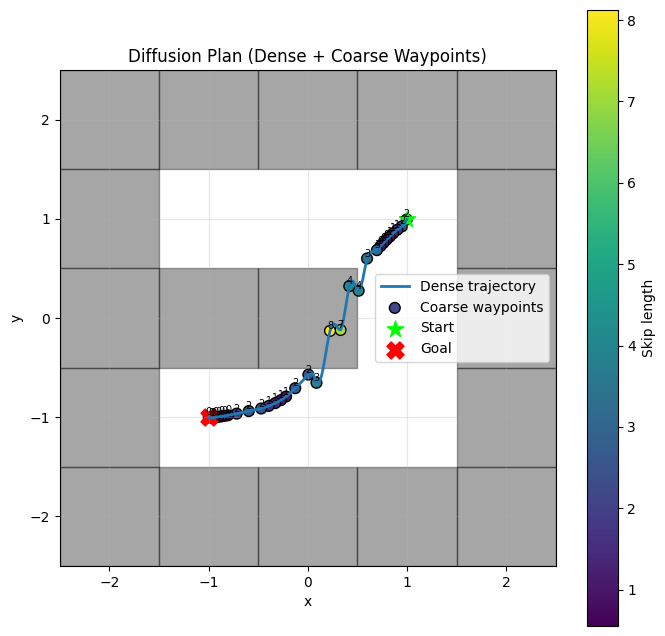